This notebook demonstrates the `am-python` interface:

1. Single model: run one `.amc` config, inspect `model.outputs`
2. Jacobian: compute sensitivity of brightness temperature to atmospheric parameters
3. Parameter sweep: use `ModelGrid` to sweep in frequency and elevation. Plots a brightness-temperature heatmap versus frequency and elevation.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

AMC_URL = (
    "https://lweb.cfa.harvard.edu/~spaine/am/cookbook/unix/sites/SPole/SPole_JJA_75.amc"
)
AMC_FILE = Path("..") / "assets" / "SPole_JJA_75.amc"
AMC_FILE.parent.mkdir(parents=True, exist_ok=True)
urlretrieve(AMC_URL, AMC_FILE)

JACOBIAN_URL = "https://lweb.cfa.harvard.edu/~spaine/am/cookbook/unix/memo_examples/chapter8/example2.5.trop_h2o_Jacobian.amc"
JACOBIAN_FILE = Path("..") / "assets" / "MaunaKea_Jacobian.amc"
urlretrieve(JACOBIAN_URL, JACOBIAN_FILE)

(PosixPath('../assets/MaunaKea_Jacobian.amc'),
 <http.client.HTTPMessage at 0x7fa888d51940>)

## Single model


! Warning: Encountered in-band lines narrower than the frequency
!          grid spacing.  The output configuration data includes
!          the unresolved line count after each column definition
!          for which this occurred.


Available outputs: ['tb_planck', 'transmittance', 'opacity', 'tb_rj']


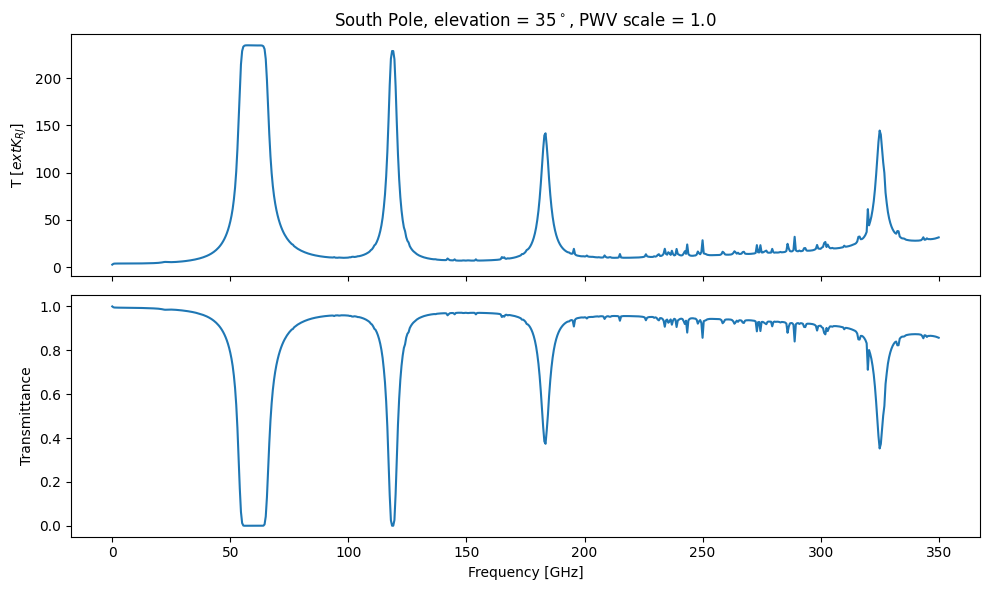

In [2]:
import am
import matplotlib.pyplot as plt

m = am.Model(AMC_FILE, [0, "GHz", 350, "GHz", 0.5, "GHz", 35, "deg", 1.0])
m.compute()

print("Available outputs:", list(m.outputs.data_vars))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(m.frequency, m.outputs["tb_rj"])
ax1.set_ylabel("T [$\text{K}_{RJ}$]")
ax1.set_title("South Pole, elevation = $35^\circ$, PWV scale = 1.0")

ax2.plot(m.frequency, m.outputs["transmittance"])
ax2.set_ylabel("Transmittance")
ax2.set_xlabel("Frequency [GHz]")

plt.tight_layout()
plt.show()

## Jacobian

Compute the sensitivity of brightness temperature to tropospheric water vapor using the Mauna Kea cookbook example. The `.amc` config defines `Nscale troposphere h2o` as a fit variable, so `model.jacobian()` returns $\partial T_{RJ} / \partial (\text{Nscale}_{H_2O})$.


In [3]:
# 170-390 GHz, 2 MHz resolution, zenith, 277 K ground, Nscale=1.0
m = am.Model(JACOBIAN_FILE, [170, "GHz", 390, "GHz", 2, "MHz", 0, "deg", 277, "K", 1.0])
m.compute()
jac = m.jacobian()
jac

<xarray.Dataset> Size: 2MB
Dimensions:    (variable: 1, frequency: 110001)
Coordinates:
  * variable   (variable) <U22 88B 'Nscale troposphere h2o'
  * frequency  (frequency) float64 880kB 170.0 170.0 170.0 ... 390.0 390.0 390.0
Data variables:
    tb_rj      (variable, frequency) float64 880kB 18.39 18.4 ... 92.25 92.26

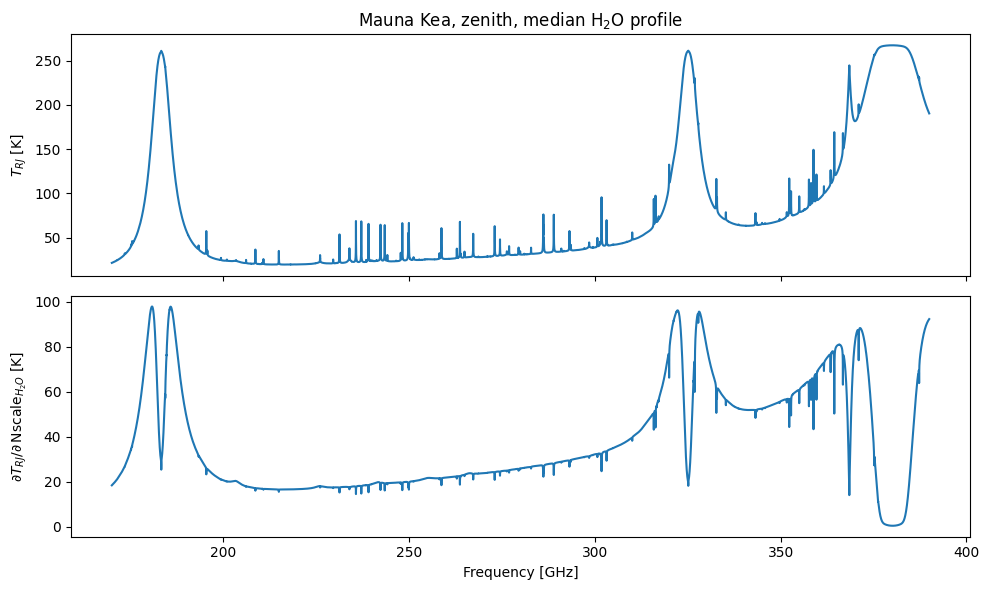

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

freq = jac.coords["frequency"]
trj = m.outputs["tb_rj"]
dtrj = jac["tb_rj"].sel(variable="Nscale troposphere h2o")

ax1.plot(freq, trj)
ax1.set_ylabel(r"$T_{RJ}$ [K]")
ax1.set_title("Mauna Kea, zenith, median H$_2$O profile")

ax2.plot(freq, dtrj)
ax2.set_ylabel(r"$\partial T_{RJ} / \partial\, \mathrm{Nscale}_{H_2O}$ [K]")
ax2.set_xlabel("Frequency [GHz]")

plt.tight_layout()
plt.show()

## Parameter sweep with `ModelGrid`

Sweep over elevation using a Cartesian `xr.Dataset`. `ModelGrid` runs all models in parallel and returns an `xr.Dataset` with `(elevation, frequency)` dimensions.


In [5]:
import numpy as np
import xarray as xr

params = xr.Dataset(coords={"elevation": np.linspace(0.1, 90.0, 91)})

ds = am.ModelGrid(
    AMC_FILE,
    params,
    args_fn=lambda elevation: [
        0,
        "GHz",
        550,
        "GHz",
        0.5,
        "GHz",
        90.0 - elevation,
        "deg",
        1.0,
    ],
).compute()

ds

! Warning: Encountered in-band lines narrower than the frequency
!          grid spacing.  The output configuration data includes
!          the unresolved line count after each column definition
!          for which this occurred.
! Warning: Encountered in-band lines narrower than the frequency
!          grid spacing.  The output configuration data includes
!          the unresolved line count after each column definition
!          for which this occurred.
! Warning: Encountered in-band lines narrower than the frequency
!          grid spacing.  The output configuration data includes
!          the unresolved line count after each column definition
!          for which this occurred.
! Warning: Encountered in-band lines narrower than the frequency
!          grid spacing.  The output configuration data includes
!          the unresolved line count after each column definition
!          for which this occurred.
! Warning: Encountered in-band lines narrower than the frequency
!      

<xarray.Dataset> Size: 3MB
Dimensions:        (elevation: 91, frequency: 1101)
Coordinates:
  * elevation      (elevation) float64 728B 0.1 1.099 2.098 ... 88.0 89.0 90.0
  * frequency      (frequency) float64 9kB 0.0 0.5 1.0 1.5 ... 549.0 549.5 550.0
Data variables:
    transmittance  (elevation, frequency) float64 802kB 1.0 0.1471 ... 1.224e-18
    tb_rj          (elevation, frequency) float64 802kB 2.7 195.1 ... 223.0
    tb_planck      (elevation, frequency) float64 802kB 2.7 195.1 ... 235.9
    opacity        (elevation, frequency) float64 802kB 1.469e-05 ... 41.24

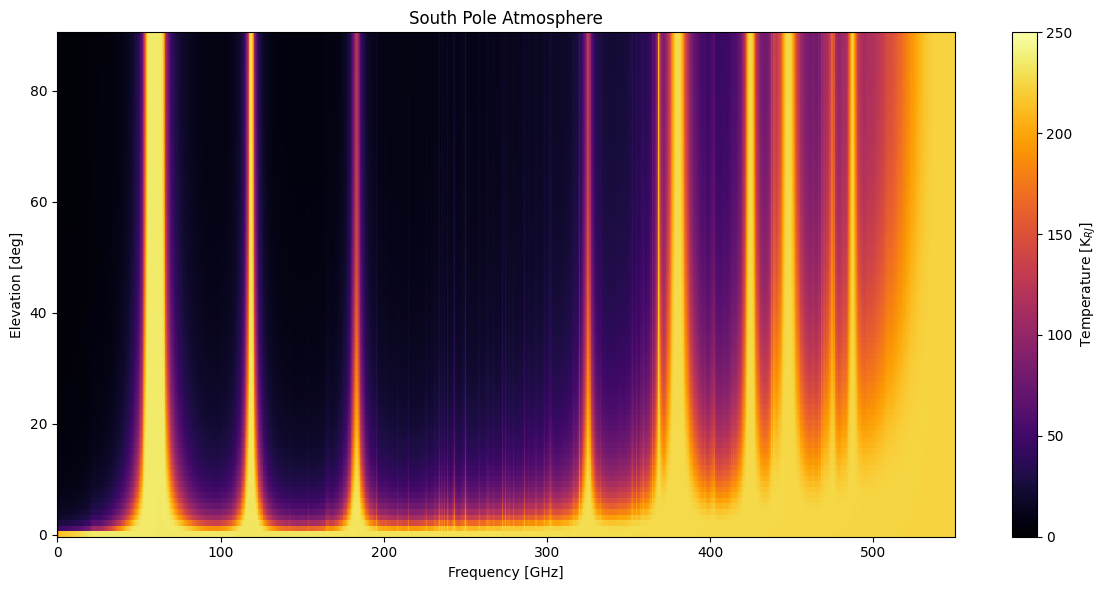

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ds["tb_rj"].plot(
    ax=ax,
    x="frequency",
    y="elevation",
    cmap="inferno",
    vmin=0,
    vmax=250,
    cbar_kwargs={"label": r"Temperature [$\text{K}_{RJ}$]"},
)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Elevation [deg]")
ax.set_title("South Pole Atmosphere")
plt.tight_layout()
plt.show()